<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/03_hypothesis_testing_cleaned_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [13]:
df = pd.read_csv("final_dataset.csv")

df.head()

,Unnamed: 0,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm),snowfall_sum (cm)
0,2005-01-31,46.650000,405.258065,126.2,7.006452,125.6,0.77
1,2005-02-28,72.679286,631.285714,108.5,5.996429,87.7,14.91
2,2005-03-31,92.837097,806.419355,66.8,7.090323,56.7,7.28
3,2005-04-30,92.331667,802.100000,36.1,11.813333,36.1,0.00
4,2005-05-31,87.719677,762.032258,12.3,16.148387,12.3,0.00



**HYPOTHESIS 1: Rainfall affects dam occupancy**

---




H0:
 Rainfall has no effect on dam occupancy levels.

H1:
 Rainfall affects dam occupancy levels.

In [14]:
target_col = "GENERAL_DAM_OCCUPANCY_RATE"
rain_col = "precipitation_sum (mm)"

median_rain = df[rain_col].median()

high_rain = df[df[rain_col] > median_rain]
low_rain = df[df[rain_col] <= median_rain]

print("Median precipitation:", median_rain)
print("High rain days:", len(high_rain))
print("Low rain days:", len(low_rain))


Median precipitation: 51.55
High rain days: 98
Low rain days: 98


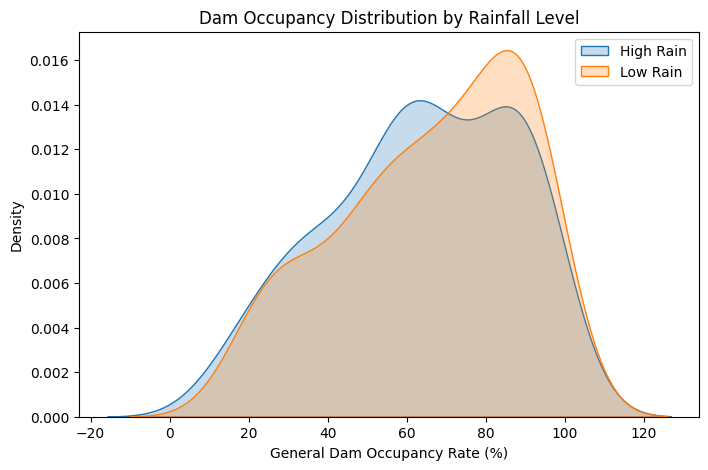

In [15]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    high_rain[target_col],
    label="High Rain",
    fill=True
)

sns.kdeplot(
    low_rain[target_col],
    label="Low Rain",
    fill=True
)

plt.title("Dam Occupancy Distribution by Rainfall Level")
plt.xlabel("General Dam Occupancy Rate (%)")
plt.ylabel("Density")
plt.legend()
plt.show()


In [16]:
t_stat, p_value = ttest_ind(
    high_rain[target_col],
    low_rain[target_col],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Rainfall groups have significantly different dam occupancy levels.")
else:
    print("Fail to reject H0: Rainfall alone does not show a statistically significant effect.")

T-statistic: -0.8175662239047653
P-value: 0.4146080609332651
Fail to reject H0: Rainfall alone does not show a statistically significant effect.



**HYPOTHESIS 2: Weather variables explain dam occupancy**

---




H0:
Weather variables do not explain dam occupancy levels.

H1:
Weather variables explain dam occupancy levels.

In [17]:
feature_cols = [
    "precipitation_sum (mm)",
    "snowfall_sum (cm)",
    "temperature_2m_mean (°C)"
]

X = df[feature_cols]
y = df[target_col]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)
r2 = r2_score(y, predictions)

print("R² Score:", r2)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

coef_table = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_
})

coef_table

R² Score: 0.02461557447037299
Coefficients: [-0.07536634  0.4491365  -0.3171522 ]
Intercept: 72.95092380294814


,Feature,Coefficient
0,precipitation_sum (mm),-0.075366
1,snowfall_sum (cm),0.449136
2,temperature_2m_mean (°C),-0.317152


  The R² score indicates that short-term weather variables explain only a small portion of the variation in dam occupancy levels. This suggests that rainfall, snowfall, and temperature alone are not sufficient to fully explain reservoir behavior.


**HYPOTHESIS 3: Seasonality affects dam occupancy**

---




H0:
Mean dam occupancy rates are equal across seasons.

H1:
At least one season has a different mean occupancy rate.

In [18]:
df_season = pd.read_csv("final_dataset.csv")


df_season.head()

,Unnamed: 0,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm),snowfall_sum (cm)
0,2005-01-31,46.650000,405.258065,126.2,7.006452,125.6,0.77
1,2005-02-28,72.679286,631.285714,108.5,5.996429,87.7,14.91
2,2005-03-31,92.837097,806.419355,66.8,7.090323,56.7,7.28
3,2005-04-30,92.331667,802.100000,36.1,11.813333,36.1,0.00
4,2005-05-31,87.719677,762.032258,12.3,16.148387,12.3,0.00


In [19]:
df_season = df_season.rename(columns={df_season.columns[0]: "date"})
df_season["date"] = pd.to_datetime(df_season["date"])

df_season["month"] = df_season["date"].dt.month
df_season[["date", "month"]].head()

,date,month
0,2005-01-31,1
1,2005-02-28,2
2,2005-03-31,3
3,2005-04-30,4
4,2005-05-31,5


In [20]:


target_col = "GENERAL_DAM_OCCUPANCY_RATE"




def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Fall"


df_season["season"] = df_season["month"].apply(get_season)




print(df_season["season"].value_counts())

season
Winter    50
Spring    50
Summer    48
Fall      48
Name: count, dtype: int64


In [21]:
season_means = df_season.groupby("season")[target_col].mean()

print(season_means)

season
Fall      49.322261
Spring    80.446341
Summer    66.861588
Winter    62.274990
Name: GENERAL_DAM_OCCUPANCY_RATE, dtype: float64


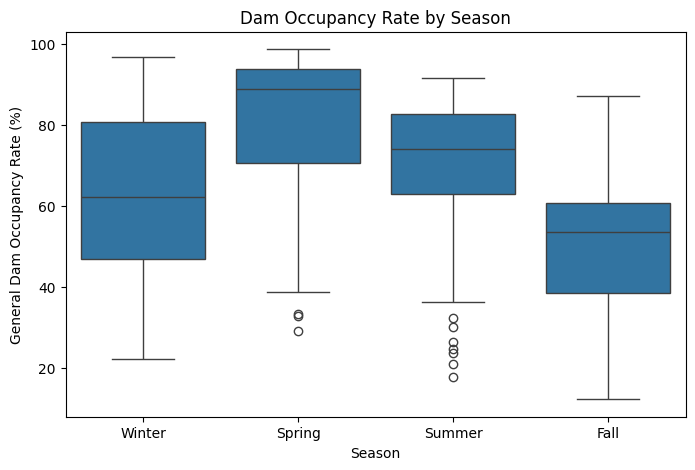

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_season,
    x="season",
    y=target_col,
    order=["Winter", "Spring", "Summer", "Fall"]
)

plt.title("Dam Occupancy Rate by Season")
plt.xlabel("Season")
plt.ylabel("General Dam Occupancy Rate (%)")

plt.show()

**ANOVA test:**

In [24]:
winter = df_season[df_season["season"] == "Winter"][target_col]

spring = df_season[df_season["season"] == "Spring"][target_col]

summer = df_season[df_season["season"] == "Summer"][target_col]

fall = df_season[df_season["season"] == "Fall"][target_col]


f_stat, p_value = f_oneway(
    winter,
    spring,
    summer,
    fall
)

print("F-statistic:", f_stat)

print("P-value:", p_value)


if p_value < 0.05:

    print("Reject H0: Dam occupancy differs significantly across seasons.")

else:

    print("Fail to reject H0: No significant seasonal difference was found.")

F-statistic: 19.204344714636868
P-value: 6.215087387549809e-11
Reject H0: Dam occupancy differs significantly across seasons.


The ANOVA test indicates a statistically significant seasonal effect on dam occupancy levels.

Spring has the highest average occupancy rates, while Fall has the lowest.

This suggests that reservoir levels are strongly influenced by seasonal patterns and long-term environmental processes.